In [1]:
"""Imports"""
import polars as pl
import seaborn as sbn

from matplotlib import pyplot as plt
from pathlib import Path

In [2]:
"""Load original daily data"""
data_path = Path.cwd().parent / "data" / "bronze" / "advan_weekly_patterns"
pertinent_info = ["DATE_RANGE_START", "LATITUDE", "LONGITUDE", "NAICS_CODE", "STREET_ADDRESS", "POSTAL_CODE", "VISITS_BY_DAY", "VISITS_BY_EACH_HOUR"]

df = pl.read_parquet(data_path / "2023-03-13--data_01c5724c-0309-a229-0042-fa0709521306_308_2_0.snappy.parquet")
df = df[pertinent_info]
df.shape

(17122, 8)

In [3]:
"""Convert string list to list of integers"""
df = (
    df
    .with_columns(
		pl.col("VISITS_BY_DAY")
		.str.replace_all(r"[\[\]]", "")
		.str.split(",")
		.cast(pl.List(pl.Int64))
	)
    .with_columns(
		pl.col("VISITS_BY_EACH_HOUR")
		.str.replace_all(r"[\[\]]", "")
		.str.split(",")
		.cast(pl.List(pl.Int64))
	)
)

df

DATE_RANGE_START,LATITUDE,LONGITUDE,NAICS_CODE,STREET_ADDRESS,POSTAL_CODE,VISITS_BY_DAY,VISITS_BY_EACH_HOUR
datetime[ms],f64,f64,str,str,str,list[i64],list[i64]
2023-03-13 00:00:00,37.755459,-122.407356,"""722410""","""1041 Hampshire St""","""94110""","[82, 65, … 49]",null
2023-03-13 00:00:00,37.789276,-122.404563,"""812112""","""153 Kearny St""","""94108""","[0, 33, … 49]","[0, 0, … 0]"
2023-03-13 00:00:00,37.670083,-122.451089,"""522390""","""1665 Mission Rd""","""94080""","[33, 33, … 33]","[0, 0, … 0]"
2023-03-13 00:00:00,37.724168,-122.402491,"""447110""","""2990 SAN BRUNO AVE""","""94134""","[33, 33, … 33]",null
2023-03-13 00:00:00,37.794082,-122.397097,"""238320""","""50 California St""","""94111""","[212, 163, … 164]","[39, 58, … 21]"
…,…,…,…,…,…,…,…
2023-03-13 00:00:00,37.80674,-122.431817,"""611210""","""Fort Mason Center Bldg. C""","""94123""","[98, 33, … 0]","[0, 0, … 0]"
2023-03-13 00:00:00,37.64891,-122.44912,"""238220""","""372 Arroyo Dr""","""94080""","[293, 196, … 131]","[0, 0, … 0]"
2023-03-13 00:00:00,37.803562,-122.401817,"""722511""","""1300 Battery St""","""94111-1104""","[49, 49, … 49]","[0, 0, … 0]"


In [4]:
"""Fact check that all division by day data is present"""
assert all(df.null_count()["VISITS_BY_DAY"] == 0)
for days in df["VISITS_BY_DAY"].to_list():
    assert len(days) == 7

print("passed")

passed


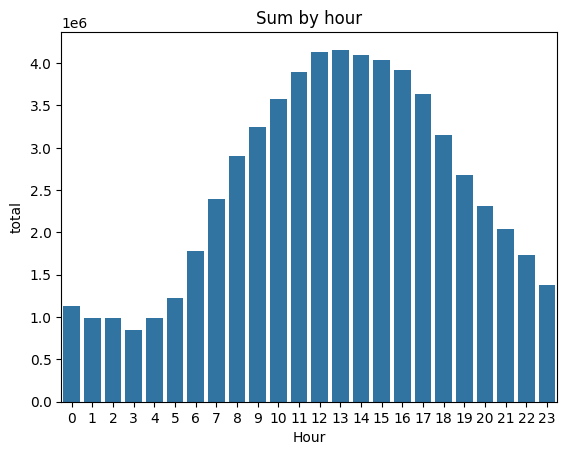

In [5]:
"""Grab hourly insights to populate daily data into nulled hourly data"""
hourly_valid = df.filter(~df["VISITS_BY_EACH_HOUR"].is_null())

for hours in hourly_valid["VISITS_BY_EACH_HOUR"].to_list():
    assert len(hours) == 168, len(hours)

hourly_exploded = hourly_valid.explode("VISITS_BY_EACH_HOUR")

hourly_distribution = (
    hourly_exploded
    .with_columns(
        pl.int_range(0, pl.len())
        .alias("global_idx")
    )
    .with_columns(
        (pl.col("global_idx") % 24)
        .alias("pos")
    )
    .group_by("pos")
    .agg(pl.col("VISITS_BY_EACH_HOUR")
         .sum()
         .alias("total"))
    .sort("pos")
)

ax = sbn.barplot(hourly_distribution, x="pos", y="total")
ax.set(title="Sum by hour", xlabel="Hour")
plt.show()

In [6]:
"""Retrieve multipliers from distribution"""
total_sum = hourly_distribution["total"].sum()

hourly_distribution = (
    hourly_distribution
    .with_columns(
        (pl.col("total") / total_sum)
        .alias("percentage")
	)
)

assert hourly_distribution["percentage"].sum() == 1.0
distribution_multipliers = hourly_distribution["percentage"].to_list()

distribution_multipliers[:5]

[0.018399810892479496,
 0.01619564722757784,
 0.01619564722757784,
 0.013884480093320222,
 0.016238736092203245]

In [7]:
"""Infill missing hourly data using daily data and distribution multipliers"""
def daily_to_hourly(days: list[int]) -> list[int]:
    """
    days: list of 7 integers (one per day)
    returns: list of 168 integers (24 hours * 7 days)
    """
    daily = []
    hourly = []
    for day in days:
        for multiplier in distribution_multipliers:
            hourly.append(round(multiplier * day))
        daily.extend(hourly)
        hourly = []
    return daily

df = (
    df
    .with_columns(
		pl.when(pl.col("VISITS_BY_EACH_HOUR").is_null())
		.then(
			pl.col("VISITS_BY_DAY")
			.map_elements(daily_to_hourly, return_dtype=pl.List(pl.Int64))
		)
		.otherwise(pl.col("VISITS_BY_EACH_HOUR"))
		.alias("VISITS_BY_EACH_HOUR")
	)
)

df.head()

DATE_RANGE_START,LATITUDE,LONGITUDE,NAICS_CODE,STREET_ADDRESS,POSTAL_CODE,VISITS_BY_DAY,VISITS_BY_EACH_HOUR
datetime[ms],f64,f64,str,str,str,list[i64],list[i64]
2023-03-13 00:00:00,37.755459,-122.407356,"""722410""","""1041 Hampshire St""","""94110""","[82, 65, … 49]","[2, 1, … 1]"
2023-03-13 00:00:00,37.789276,-122.404563,"""812112""","""153 Kearny St""","""94108""","[0, 33, … 49]","[0, 0, … 0]"
2023-03-13 00:00:00,37.670083,-122.451089,"""522390""","""1665 Mission Rd""","""94080""","[33, 33, … 33]","[0, 0, … 0]"
2023-03-13 00:00:00,37.724168,-122.402491,"""447110""","""2990 SAN BRUNO AVE""","""94134""","[33, 33, … 33]","[1, 1, … 1]"
2023-03-13 00:00:00,37.794082,-122.397097,"""238320""","""50 California St""","""94111""","[212, 163, … 164]","[39, 58, … 21]"


In [ ]:
"""Explode dataset and adjust timestamp accordingly"""
df = (
    df
    .with_columns(
		pl.lit(list(range(168)))
        .alias("hour_offsets")
	)
)

df_exploded = df.explode("VISITS_BY_EACH_HOUR", "hour_offsets")

df_exploded = (
    df_exploded
    .with_columns(
    	(pl.col("DATE_RANGE_START") + pl.col("hour_offsets").cast(pl.Int64) * pl.duration(hours=1))
	)
)
df_exploded

DATE_RANGE_START,LATITUDE,LONGITUDE,NAICS_CODE,STREET_ADDRESS,POSTAL_CODE,VISITS_BY_DAY,VISITS_BY_EACH_HOUR,hour_offsets
datetime[ms],f64,f64,str,str,str,list[i64],i64,i64
2023-03-13 00:00:00,37.755459,-122.407356,"""722410""","""1041 Hampshire St""","""94110""","[82, 65, … 49]",2,0
2023-03-13 01:00:00,37.755459,-122.407356,"""722410""","""1041 Hampshire St""","""94110""","[82, 65, … 49]",1,1
2023-03-13 02:00:00,37.755459,-122.407356,"""722410""","""1041 Hampshire St""","""94110""","[82, 65, … 49]",1,2
2023-03-13 03:00:00,37.755459,-122.407356,"""722410""","""1041 Hampshire St""","""94110""","[82, 65, … 49]",1,3
2023-03-13 04:00:00,37.755459,-122.407356,"""722410""","""1041 Hampshire St""","""94110""","[82, 65, … 49]",1,4
…,…,…,…,…,…,…,…,…
2023-03-19 19:00:00,37.780132,-122.417755,"""812930""","""355 McAllister Street""","""94102""","[179, 196, … 131]",0,163
2023-03-19 20:00:00,37.780132,-122.417755,"""812930""","""355 McAllister Street""","""94102""","[179, 196, … 131]",0,164
2023-03-19 21:00:00,37.780132,-122.417755,"""812930""","""355 McAllister Street""","""94102""","[179, 196, … 131]",0,165


In [ ]:
"""Keep relavent columns and save new parquet file"""
df = df_exploded[pertinent_info].drop("VISITS_BY_DAY")

out_path = Path.cwd().parent / "data" / "bronze" / "advan_hourly"
df.write_parquet(out_path / "test.parquet")

assert (out_path / "test.parquet").exists
(out_path / "test.parquet").unlink()

Process all advan files

In [41]:
"""Wrap everything together and flesh out hourly details for all advan data in hand"""
def daily_to_hourly(days):
	daily, hourly = [], []
	for day in days:
		for multiplier in distribution_multipliers:
			hourly.append(round(multiplier * day))
		daily.extend(hourly)
		hourly = []
	return daily

data_path = Path.cwd().parent / "data" / "bronze" / "advan_weekly_patterns"
out_path = Path.cwd().parent / "data" / "bronze" / "advan_hourly"
pertinent_info = ["DATE_RANGE_START", "LATITUDE", "LONGITUDE", "NAICS_CODE", "STREET_ADDRESS", "POSTAL_CODE", "VISITS_BY_DAY", "VISITS_BY_EACH_HOUR"]

for file_name in data_path.glob("*.parquet"):
	# load and transform
	df = pl.read_parquet(data_path / file_name)
	df = (
		df[pertinent_info]
		.with_columns(
			pl.col("VISITS_BY_DAY")
			.str.replace_all(r"[\[\]]", "")
			.str.split(",")
			.cast(pl.List(pl.Int64))
		)
		.with_columns(
			pl.col("VISITS_BY_EACH_HOUR")
			.str.replace_all(r"[\[\]]", "")
			.str.split(",")
			.cast(pl.List(pl.Int64))
		)
	)

	# assertions for clean data
	assert all(df.null_count()["VISITS_BY_DAY"] == 0)
	for days in df["VISITS_BY_DAY"].to_list():
		assert len(days) == 7
	hourly_valid = df.filter(~df["VISITS_BY_EACH_HOUR"].is_null())
	for hours in hourly_valid["VISITS_BY_EACH_HOUR"].to_list():
		assert len(hours) == 168, len(hours)

	# grab distribution from file
	hourly_exploded = hourly_valid.explode("VISITS_BY_EACH_HOUR")
	hourly_distribution = (
		hourly_exploded
		.with_columns(
			pl.int_range(0, pl.len())
			.alias("global_idx")
		)
		.with_columns(
			(pl.col("global_idx") % 24)
			.alias("pos")
		)
		.group_by("pos")
		.agg(pl.col("VISITS_BY_EACH_HOUR")
			.sum()
			.alias("total"))
		.sort("pos")
	)
	total_sum = hourly_distribution["total"].sum()
	hourly_distribution = (
		hourly_distribution
		.with_columns(
			(pl.col("total") / total_sum)
			.alias("percentage")
		)
	)
	distribution_multipliers = hourly_distribution["percentage"].to_list()

	# infill missing data
	df = (
		df
		.with_columns(
			pl.when(pl.col("VISITS_BY_EACH_HOUR").is_null())
			.then(
				pl.col("VISITS_BY_DAY")
				.map_elements(daily_to_hourly, return_dtype=pl.List(pl.Int64))
			)
			.otherwise(pl.col("VISITS_BY_EACH_HOUR"))
			.alias("VISITS_BY_EACH_HOUR")
		)
	)

	# explode data (new row per hour)
	df = (
		df
		.with_columns(
			pl.lit(list(range(168)))
			.alias("hour_offsets")
		)
		.explode("VISITS_BY_EACH_HOUR", "hour_offsets")
		.with_columns(
			(pl.col("DATE_RANGE_START") + pl.col("hour_offsets").cast(pl.Int64) * pl.duration(hours=1))
		)
	)

	# write new file
	df = df_exploded[pertinent_info].drop("VISITS_BY_DAY")
	out_name = file_name.parts[-1].split("--")[0] + ".parquet"
	df.write_parquet(out_path / out_name)

print(len(list(out_path.glob("*.*"))), "files processed")

334 files processed
